In [1]:
#import librarys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
#formatting data

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_rows", None)

In [3]:
# connect the csv & Merging Data Set

df_demo = pd.read_csv("/Users/Julian/Desktop/IronHack/Unit 5 - EDA and Inferential Stats/Project-3-Vangaurd/Project-2-Vanguard-CX-Team/Data/Raw Data/df_final_demo.txt")
df_clients = pd.read_csv("/Users/Julian/Desktop/IronHack/Unit 5 - EDA and Inferential Stats/Project-3-Vangaurd/Project-2-Vanguard-CX-Team/Data/Raw Data/df_final_experiment_clients.txt")
df_data_1 = pd.read_csv("/Users/Julian/Desktop/IronHack/Unit 5 - EDA and Inferential Stats/Project-3-Vangaurd/Project-2-Vanguard-CX-Team/Data/Raw Data/df_final_web_data_pt_1.txt")
df_data_2 = pd.read_csv("/Users/Julian/Desktop/IronHack/Unit 5 - EDA and Inferential Stats/Project-3-Vangaurd/Project-2-Vanguard-CX-Team/Data/Raw Data/df_final_web_data_pt_2.txt")

#merge the data set

#merge data - data 1 & 2

data_df = pd.concat(
    [df_data_1, df_data_2],
    ignore_index=True
)

web_exp_df = data_df.merge(
    df_clients,
    on='client_id',
    how='left'
)


merged_df = web_exp_df.merge(
    df_demo,
    on='client_id',
    how='left'
)


merged_df

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_clients["Variation"].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

+++ looking at Test and Control gorup 

In [4]:
### droping all NaN in Variation column 

# Remove rows where Variation is NaN
merged_df_clean = merged_df[merged_df['Variation'].notna()].copy()

# Verify the cleaning
print(f"Original rows: {len(merged_df)}")
print(f"After removing NaN in Variation: {len(merged_df_clean)}")
print(f"\nVariation value counts:")
print(merged_df_clean['Variation'].value_counts())

print(f"\n -------------------------------- \n")
# Split into Test and Control groups
test_group = merged_df_clean[merged_df_clean['Variation'] == 'Test'].copy()
control_group = merged_df_clean[merged_df_clean['Variation'] == 'Control'].copy()

print(f"Test group size: {len(test_group)} rows, {test_group['client_id'].nunique()} unique clients")
print(f"Control group size: {len(control_group)} rows, {control_group['client_id'].nunique()} unique clients")

Original rows: 755405
After removing NaN in Variation: 321309

Variation value counts:
Variation
Test       177847
Control    143462
Name: count, dtype: int64

 -------------------------------- 

Test group size: 177847 rows, 26968 unique clients
Control group size: 143462 rows, 23532 unique clients


In [ ]:
# Key groups to pull data from 
test_group
control_group

In [ ]:
#ANALYSIS : COMPLETED UI

def analyze_completion(df, group_name):
    """
    Analyze which clients completed all process steps
    """
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR: {group_name}")
    print(f"{'='*60}")
    
    # Define all required process steps
    all_steps = {'start', 'step_1', 'step_2', 'step_3', 'confirm'}
    
    # Group by client_id and find unique process steps each client completed
    client_steps = df.groupby('client_id')['process_step'].apply(set).reset_index()
    client_steps.columns = ['client_id', 'completed_steps']
    
    # Find clients who completed all steps
    client_steps['completed_all_steps'] = client_steps['completed_steps'] == all_steps
    
    # Get clients who completed all steps
    clients_completed_all = client_steps[client_steps['completed_all_steps']]['client_id']
    
    print(f"\nNumber of clients who completed all steps: {len(clients_completed_all)}")
    print(f"Completion rate: {len(clients_completed_all) / df['client_id'].nunique() * 100:.2f}%")
    
    # Missing steps analysis
    client_steps['missing_steps'] = client_steps['completed_steps'].apply(
        lambda x: all_steps - x
    )
    
    print("\nCompletion status:")
    print(client_steps['completed_all_steps'].value_counts())
    
    return client_steps

# Run analysis for both groups
test_analysis = analyze_completion(test_group, "TEST GROUP")
control_analysis = analyze_completion(control_group, "CONTROL GROUP")


ANALYSIS FOR: TEST GROUP

Number of clients who completed all steps: 18338
Completion rate: 68.00%

Completion status:
completed_all_steps
True     18338
False     8630
Name: count, dtype: int64

ANALYSIS FOR: CONTROL GROUP

Number of clients who completed all steps: 15206
Completion rate: 64.62%

Completion status:
completed_all_steps
True     15206
False     8326
Name: count, dtype: int64


In [16]:
#ANALYSIS : DROP OFF RATES 

def analyze_dropoff(df, group_name):
    """
    Analyze drop-off rates at each step
    """
    print(f"\n{'='*60}")
    print(f"DROP-OFF ANALYSIS FOR: {group_name}")
    print(f"{'='*60}")
    
    # Count unique clients at each step
    step_reach = df.groupby('process_step')['client_id'].nunique().sort_index()
    
    # Define step order
    step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
    step_reach = step_reach.reindex(step_order)
    
    print("\nUnique clients at each step:")
    print(step_reach)
    
    # Calculate conversion rates between consecutive steps
    print(f"\nFunnel conversion rates:")
    for i in range(len(step_order) - 1):
        current_step = step_order[i]
        next_step = step_order[i + 1]
        
        if current_step in step_reach.index and next_step in step_reach.index:
            conversion = (step_reach[next_step] / step_reach[current_step]) * 100
            drop_off = 100 - conversion
            print(f"{current_step} -> {next_step}: {conversion:.2f}% (Drop-off: {drop_off:.2f}%)")
    
    # Overall conversion
    if 'start' in step_reach.index and 'confirm' in step_reach.index:
        overall = (step_reach['confirm'] / step_reach['start']) * 100
        print(f"\nOverall (start -> confirm): {overall:.2f}%")
    
    return step_reach

# Run drop-off analysis for both groups
test_dropoff = analyze_dropoff(test_group, "TEST GROUP")
control_dropoff = analyze_dropoff(control_group, "CONTROL GROUP")


DROP-OFF ANALYSIS FOR: TEST GROUP

Unique clients at each step:
process_step
start      26679
step_1     24267
step_2     22258
step_3     20881
confirm    18687
Name: client_id, dtype: int64

Funnel conversion rates:
start -> step_1: 90.96% (Drop-off: 9.04%)
step_1 -> step_2: 91.72% (Drop-off: 8.28%)
step_2 -> step_3: 93.81% (Drop-off: 6.19%)
step_3 -> confirm: 89.49% (Drop-off: 10.51%)

Overall (start -> confirm): 70.04%

DROP-OFF ANALYSIS FOR: CONTROL GROUP

Unique clients at each step:
process_step
start      23397
step_1     20152
step_2     18650
step_3     17422
confirm    15434
Name: client_id, dtype: int64

Funnel conversion rates:
start -> step_1: 86.13% (Drop-off: 13.87%)
step_1 -> step_2: 92.55% (Drop-off: 7.45%)
step_2 -> step_3: 93.42% (Drop-off: 6.58%)
step_3 -> confirm: 88.59% (Drop-off: 11.41%)

Overall (start -> confirm): 65.97%


In [18]:
#Analysis : Time from start to Finsih 

def analyze_time_to_complete(df, group_name):
    """
    Calculate time taken from start to confirm for each client
    """
    print(f"\n{'='*60}")
    print(f"TIME TO COMPLETE ANALYSIS FOR: {group_name}")
    print(f"{'='*60}")
    
    # Convert date_time to datetime
    df['date_time'] = pd.to_datetime(df['date_time'])
    
    # Get start and confirm times for each client
    client_times = df.groupby('client_id').agg({
        'date_time': ['min', 'max'],
        'process_step': lambda x: set(x)
    }).reset_index()
    
    client_times.columns = ['client_id', 'first_interaction', 'last_interaction', 'steps_completed']
    
    # Calculate time difference
    client_times['time_to_complete'] = client_times['last_interaction'] - client_times['first_interaction']
    client_times['time_minutes'] = client_times['time_to_complete'].dt.total_seconds() / 60
    
    # Filter only clients who completed all steps
    all_steps = {'start', 'step_1', 'step_2', 'step_3', 'confirm'}
    client_times['completed_all'] = client_times['steps_completed'] == all_steps
    
    completed_clients = client_times[client_times['completed_all']]
    
    print(f"\nClients who completed all steps: {len(completed_clients)}")
    
    if len(completed_clients) > 0:
        print(f"\nTime to complete statistics (in minutes):")
        print(f"Mean: {completed_clients['time_minutes'].mean():.2f}")
        print(f"Median: {completed_clients['time_minutes'].median():.2f}")
        print(f"Min: {completed_clients['time_minutes'].min():.2f}")
        print(f"Max: {completed_clients['time_minutes'].max():.2f}")
        print(f"Std Dev: {completed_clients['time_minutes'].std():.2f}")
    
    return client_times

# Run time analysis for both groups
test_time = analyze_time_to_complete(test_group, "TEST GROUP")
control_time = analyze_time_to_complete(control_group, "CONTROL GROUP")


TIME TO COMPLETE ANALYSIS FOR: TEST GROUP

Clients who completed all steps: 18338

Time to complete statistics (in minutes):
Mean: 6031.24
Median: 5.90
Min: 0.53
Max: 135175.75
Std Dev: 17896.57

TIME TO COMPLETE ANALYSIS FOR: CONTROL GROUP

Clients who completed all steps: 15206

Time to complete statistics (in minutes):
Mean: 7002.52
Median: 6.30
Min: 0.67
Max: 130049.35
Std Dev: 19306.78


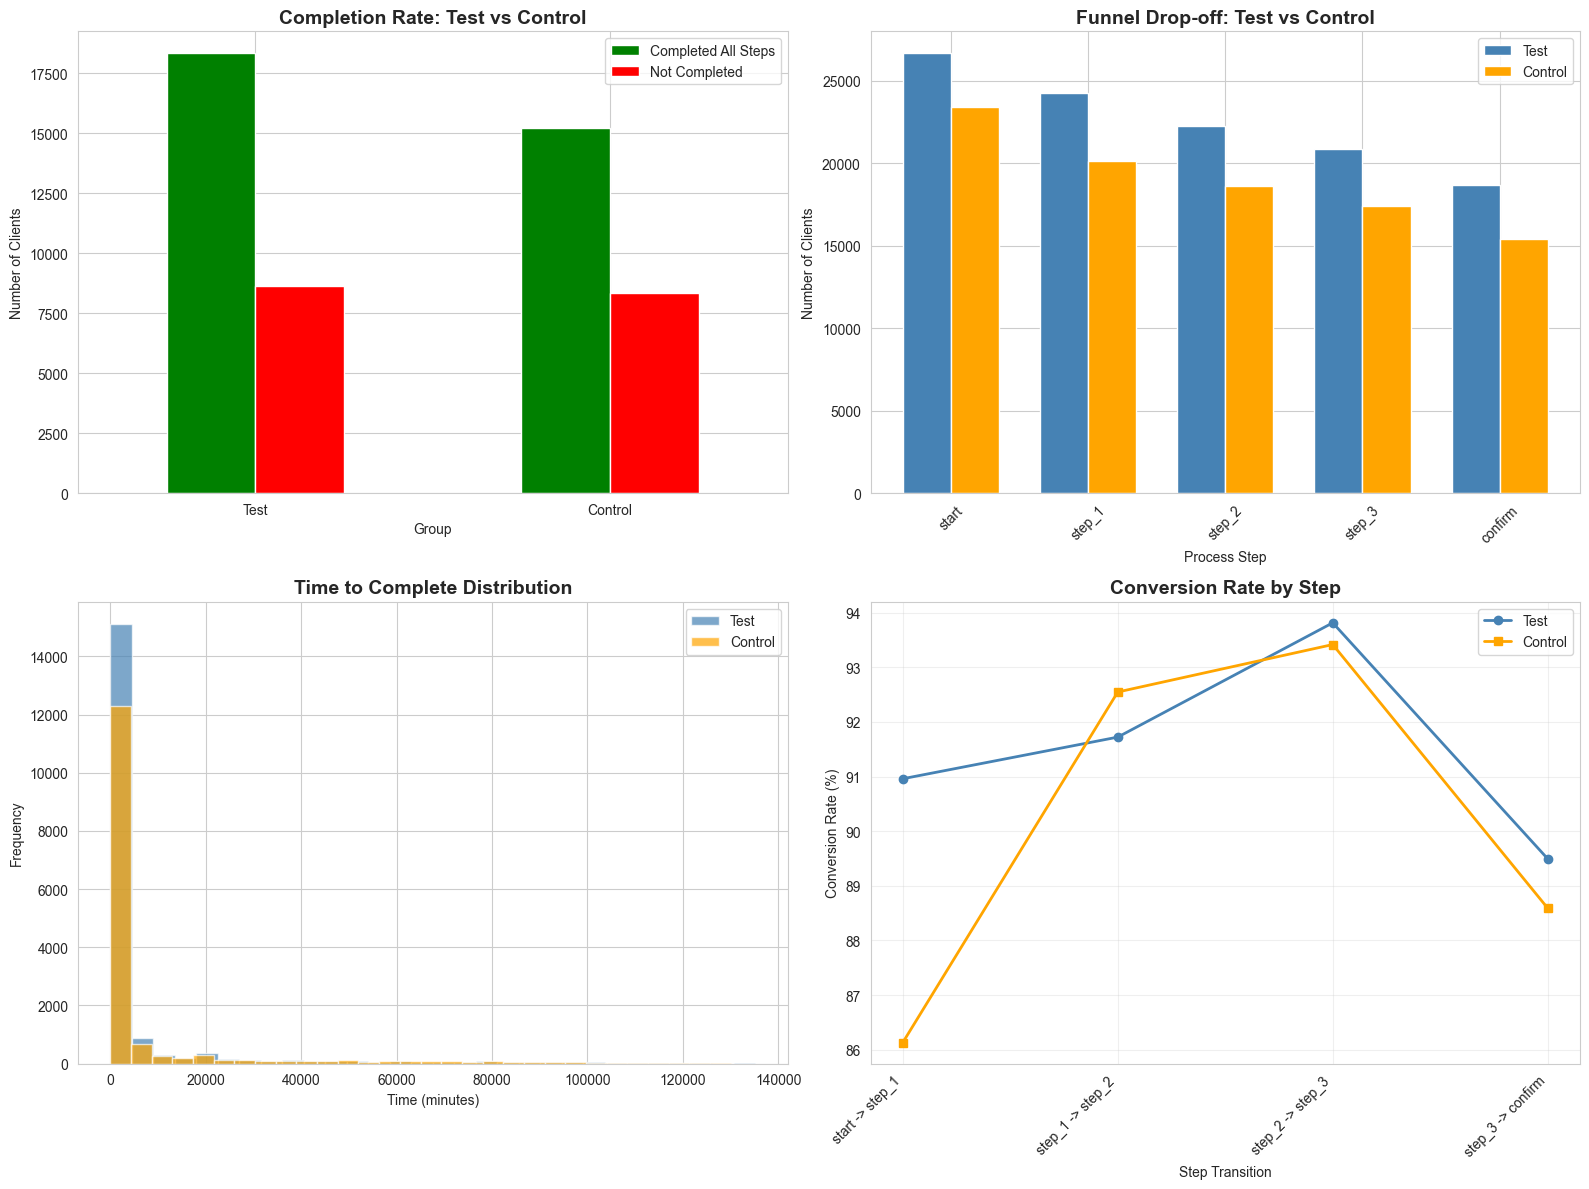

In [19]:
### Visualization 


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Completion Rate Comparison
completion_data = pd.DataFrame({
    'Group': ['Test', 'Control'],
    'Completed': [
        (test_analysis['completed_all_steps'] == True).sum(),
        (control_analysis['completed_all_steps'] == True).sum()
    ],
    'Not Completed': [
        (test_analysis['completed_all_steps'] == False).sum(),
        (control_analysis['completed_all_steps'] == False).sum()
    ]
})

completion_data.set_index('Group')[['Completed', 'Not Completed']].plot(
    kind='bar', ax=axes[0, 0], color=['green', 'red']
)
axes[0, 0].set_title('Completion Rate: Test vs Control', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Clients')
axes[0, 0].set_xlabel('Group')
axes[0, 0].legend(['Completed All Steps', 'Not Completed'])
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Funnel Drop-off Comparison
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
test_funnel = [test_dropoff[step] for step in step_order if step in test_dropoff.index]
control_funnel = [control_dropoff[step] for step in step_order if step in control_dropoff.index]

x = range(len(step_order))
width = 0.35

axes[0, 1].bar([i - width/2 for i in x], test_funnel, width, label='Test', color='steelblue')
axes[0, 1].bar([i + width/2 for i in x], control_funnel, width, label='Control', color='orange')
axes[0, 1].set_title('Funnel Drop-off: Test vs Control', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Number of Clients')
axes[0, 1].set_xlabel('Process Step')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(step_order, rotation=45)
axes[0, 1].legend()

# 3. Time to Complete Distribution
completed_test = test_time[test_time['completed_all'] == True]['time_minutes']
completed_control = control_time[control_time['completed_all'] == True]['time_minutes']

if len(completed_test) > 0:
    axes[1, 0].hist(completed_test, bins=30, alpha=0.7, label='Test', color='steelblue')
if len(completed_control) > 0:
    axes[1, 0].hist(completed_control, bins=30, alpha=0.7, label='Control', color='orange')

axes[1, 0].set_title('Time to Complete Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Time (minutes)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Conversion Rate by Step
test_conversion = []
control_conversion = []

for i in range(len(step_order) - 1):
    current = step_order[i]
    next_step = step_order[i + 1]
    
    if current in test_dropoff.index and next_step in test_dropoff.index:
        test_conversion.append((test_dropoff[next_step] / test_dropoff[current]) * 100)
    
    if current in control_dropoff.index and next_step in control_dropoff.index:
        control_conversion.append((control_dropoff[next_step] / control_dropoff[current]) * 100)

conversion_labels = [f"{step_order[i]} -> {step_order[i+1]}" for i in range(len(step_order)-1)]
x = range(len(conversion_labels))

axes[1, 1].plot(x, test_conversion, marker='o', label='Test', color='steelblue', linewidth=2)
axes[1, 1].plot(x, control_conversion, marker='s', label='Control', color='orange', linewidth=2)
axes[1, 1].set_title('Conversion Rate by Step', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Conversion Rate (%)')
axes[1, 1].set_xlabel('Step Transition')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(conversion_labels, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()